In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

from codes.Quantum import *
from codes.CSPSA import *

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

In [2]:
def postprocessing(U):
    U, _ = np.linalg.qr(U)
    # U = U@(U.T.conj()U).
    return U

In [7]:
def trineq(U, psi):
    Psi = triple_kron( psi, psi, psi )
    Psi = Psi.reshape(6*[2]).transpose([5,0,1,2,3,4]).flatten() 
    Rho = np.outer( Psi, Psi.conj() )

    U = postprocessing(U)

    M = []
    for u in U:
        M.append( np.outer(u,u.conj()) )

    probs = InnerProductMatrices( Rho, [ M, M, M ] ).real
    probs = probs.reshape(6*[2])

    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )

    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1]*probs_clcr[1,0] 
                -probs_clcr[0,0]*probs_clcr[1,1] 
                -probs_clcr[0,1]*probs[1,0,0,1,1,0]
                -probs_clcr[0,1]*probs[1,1,0,0,1,0]
                +probs_clcr[0,0]*probs[1,0,1,1,1,1]
                +probs_clcr[0,0]*probs[1,1,1,0,1,1]
                +probs_clcr[1,0]*probs[0,0,1,0,0,1]
                +probs_clcr[1,0]*probs[0,1,1,1,0,1]
                +probs_clcr[1,1]*probs[0,0,0,0,0,0]
                +probs_clcr[1,1]*probs[0,1,0,1,0,0]
                )
    return inequality

In [4]:
gains = [4, 0, 0.1, 0.602, 0.101]
max_iter = 1000
max_rep = 1
Out = []
iter = np.linspace(0.0, 0.5, 6)

Out = np.empty(( 6, max_rep, max_iter))

for i in range(6):
    a = i/10
    for k in range(max_rep):
        psi = np.sqrt(a)*np.array([0, 1, 0, 0]) + np.sqrt(1-a)*np.array([0, 0, 1, 0])
        U = np.random.randn(4,4) + 1j*np.random.randn(4,4) 
        # U = np.eye(4)
        #measure = RandomState( 4 )
        cspsa = CSPSA(gains=gains, minimize=False)
        
        results = cspsa.minimize(trineq, U, max_iter,args = (psi), postprocessing=postprocessing)
        infidelities = results.fun

        Out[i, k, :] = infidelities
    
    #np.save("Data_sim_0"+str(i), Out)

In [5]:
np.max(Out[0,0]), np.max(Out[5,0])

(-2.6827910123571496e-07, -0.1508981364750006)

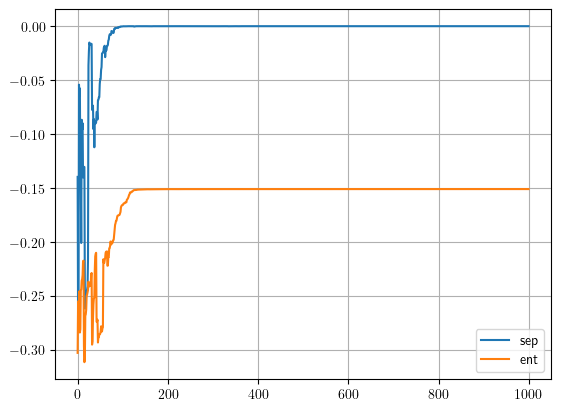

In [6]:
plt.plot(Out[0,0,:], label = 'sep' )
plt.plot(Out[5,0,:], label = 'ent' )
plt.legend()
plt.grid()